# NB04 — Confounder Checks

**Type:** Confirmatory secondary  
**Status:** Spark-required (fetches isolation source, biome, latitude from arkinlab_microbeatlas).
Original analysis executed via BERDL Spark. Results cached in `data/04_confounder_results.csv`.
The final cell loads and displays those results. Re-execution requires JupyterHub.

Test pre-specified confounders by adding each to the primary model and assessing beta change.
Decision rule: >50% beta reduction and non-significance = confounded.

## Pre-specifications

- Pre-specified confounders: genome size, GC content, isolation source, mean latitude, dominant biome
- Decision threshold: >50% β attenuation AND p > 0.05 → CONFOUNDED


In [1]:
import sys
from pathlib import Path

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts.gene_list_utils import load_gene_list, get_subset, get_ko_set
from scripts.pgls_utils import run_pgls, run_multi_pgls, pgls_results_table, fdr_correct
from scripts.niche_utils import levins_b_std, genus_niche_summary
from scripts.spatial_utils import haversine_join
from scripts.berdl_utils import get_spark_session, load_local_pgls_input

pd.set_option('display.max_rows', 60)
print('Imports OK')

Imports OK


## Analysis Blocks

- **Block 1**: Setup + data loading + confounder derivation (GC content, isolation source, dominant biome, mean latitude via Spark)
- **Block 2**: Baseline PGLS + one model per confounder (predictor_z always first)
- **Block 3**: Decision rules (>50% β change AND non-sig → confounded) + figure + save

**Decision rule (RESEARCH_PLAN.md §7):** β reduced >50% AND non-significant → confounded; demote primary claim.


In [2]:
DATA = Path('../data')
FIGS = Path('../figures')
FIGS.mkdir(exist_ok=True)
TREE_BAC = DATA / 'gtdb_bac_genus_pruned.tree'

# Use Path for the microbeatlas directory
MICROBEATLAS = Path('../../microbeatlas_metal_ecology/data')

gene_df = load_gene_list(DATA / 'curated_mrg_ko_ids_v2.csv')

bac_df = pd.read_csv(DATA / '01_pgls_input_bacteria.csv')
print(f'Bacteria PGLS input: {len(bac_df)} genera')

traits = pd.read_csv(DATA / 'mgnify_mag_metal_traits.csv')
traits['genus_lower'] = traits['genus'].str.lower().str.strip()

gc_df = traits.groupby('genus_lower', as_index=False).agg(mean_gc=('gc_content', 'mean'))

def _classify_src(lineage):
    bl = str(lineage).lower()
    if any(k in bl for k in ('soil', 'terrestrial', 'sediment')):
        return 'soil'
    if any(k in bl for k in ('marine', 'ocean', 'aquatic', 'freshwater', 'lake')):
        return 'aquatic'
    if any(k in bl for k in ('host', 'gut', 'rumen', 'skin', 'lung')):
        return 'host'
    return 'other'

traits['iso_src'] = traits['biome_lineage'].apply(_classify_src)
src_mode = (traits.groupby('genus_lower')['iso_src']
            .agg(lambda x: x.value_counts().index[0])
            .reset_index().rename(columns={'iso_src': 'dom_src'}))
biome_mode = (traits.groupby('genus_lower')['biome_name']
              .agg(lambda x: x.value_counts().index[0])
              .reset_index().rename(columns={'biome_name': 'dom_biome'}))

conf_df = (bac_df
           .merge(gc_df,        on='genus_lower', how='left')
           .merge(src_mode,     on='genus_lower', how='left')
           .merge(biome_mode,   on='genus_lower', how='left')
           .copy())

conf_df['gc_z']        = (conf_df['mean_gc'] - conf_df['mean_gc'].mean()) / conf_df['mean_gc'].std()
conf_df['src_aquatic'] = (conf_df['dom_src'] == 'aquatic').astype(float)
conf_df['src_host']    = (conf_df['dom_src'] == 'host').astype(float)

bm_dummies = pd.get_dummies(conf_df['dom_biome'], prefix='bm').astype(float)
maj_bm = [c for c in bm_dummies.columns if bm_dummies[c].sum() > 30]
conf_df = pd.concat([conf_df, bm_dummies[maj_bm]], axis=1)

# Mean latitude per genus from microbeatlas final_mags_geospatial_traits.csv
# (per-MAG lat/lon, same source as microbeatlas NB18 — no Spark required)
_LAT_AVAILABLE = False
try:
    # Ensure the file exists
    geo_file = MICROBEATLAS / 'final_mags_geospatial_traits.csv'
    if not geo_file.exists():
        raise FileNotFoundError(f"File not found: {geo_file}")
    
    mags_geo = pd.read_csv(geo_file,
                           usecols=['genome_id', 'genus', 'lat'])
    mags_geo['genus_lower'] = mags_geo['genus'].str.lower().str.strip()
    genus_lat = (mags_geo.dropna(subset=['lat'])
                 .groupby('genus_lower', as_index=False)
                 .agg(mean_lat=('lat', 'mean')))
    conf_df = conf_df.merge(genus_lat[['genus_lower', 'mean_lat']], on='genus_lower', how='left')
    n_lat = conf_df['mean_lat'].notna().sum()
    conf_df['lat_z'] = (conf_df['mean_lat'] - conf_df['mean_lat'].mean()) / conf_df['mean_lat'].std()
    _LAT_AVAILABLE = n_lat > 50
    print(f'Mean latitude (local): {n_lat} genera with data')
except Exception as _le:
    conf_df['lat_z'] = np.nan
    print(f'Mean latitude unavailable ({type(_le).__name__}: {_le}). Lat confounder skipped.')

print(f'\nConfounder df: {len(conf_df)} genera')
print(f"  GC available:   {conf_df['mean_gc'].notna().sum()}")
print(f"  Source dist:    {conf_df['dom_src'].value_counts().to_dict()}")
print(f"  Biome dummies (n>30): {len(maj_bm)}")
print(f"  Latitude available: {_LAT_AVAILABLE}")


Bacteria PGLS input: 1574 genera


Mean latitude (local): 575 genera with data

Confounder df: 1574 genera
  GC available:   1006
  Source dist:    {'host': 357, 'aquatic': 345, 'soil': 304}
  Biome dummies (n>30): 6
  Latitude available: True


In [3]:
def _get_beta(r, key='predictor_z'):
    """Beta for predictor_z from run_pgls result (single- or multi-predictor)."""
    if 'betas' in r:
        return r['betas'].get(key, float('nan'))
    return r.get('beta', float('nan'))

def _get_p(r, key='predictor_z'):
    """p-value for predictor_z from run_pgls result (single- or multi-predictor)."""
    if 'p_values' in r:
        return r['p_values'].get(key, float('nan'))
    return r.get('p_value', float('nan'))

def _conf_pgls(df, extra_preds, label, min_n=100):
    preds = ['predictor_z'] + [c for c in extra_preds if c in df.columns]
    cols  = ['genus_lower', 'mean_levins_B_std', 'phylum', 'kingdom'] + preds
    valid = df[cols].dropna()
    return run_pgls(valid, TREE_BAC, response='mean_levins_B_std',
                    predictors=preds, taxon_col='genus_lower',
                    label=label, min_n=min_n)

print('Running baseline PGLS (predictor_z only)...')
r0    = _conf_pgls(conf_df, [], 'C0_baseline')
beta0 = _get_beta(r0)
print(f'  Baseline \u03b2={beta0:.5f}  p={_get_p(r0):.3e}  n={r0.get("n")}')

conf_specs = [
    ('Genome size',      'C1',  ['genome_mb_z']),
    ('GC content',       'C2',  ['gc_z']),
    ('Isolation source', 'C3',  ['src_aquatic', 'src_host']),
    ('Dominant biome',   'C4',  maj_bm),
]
if _LAT_AVAILABLE:
    conf_specs.insert(3, ('Mean latitude', 'C3b', ['lat_z']))

print(f'\nRunning {len(conf_specs)} confounder models...')
conf_results = []
for cname, ctag, ccols in conf_specs:
    r = _conf_pgls(conf_df, ccols, f'{ctag}_{cname.lower().replace(" ", "_")}')
    r['confounder'] = cname
    r['extra_preds'] = ccols
    conf_results.append(r)
    print(f'  {cname:20s}: \u03b2={_get_beta(r):.5f}  p={_get_p(r):.3e}  n={r.get("n")}')


Running baseline PGLS (predictor_z only)...


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  Baseline β=-0.02070  p=2.139e-08  n=1574

Running 5 confounder models...


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  Genome size         : β=-0.01104  p=5.959e-03  n=1574


...

  Isolation source    : β=-0.01770  p=3.308e-06  n=1574


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  Mean latitude       : β=-0.03143  p=1.910e-07  n=575


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  Dominant biome      : β=-0.01951  p=2.214e-07  n=1574


Baseline β = -0.02070  (P1 replication, n=1574)

      confounder  beta_with_conf  pct_beta_change  model_sig_p05                     decision
     Genome size        -0.01104             46.7           True         ROBUST (<50% change)
      GC content        -0.01580             23.7           True         ROBUST (<50% change)
Isolation source        -0.01770             14.5           True         ROBUST (<50% change)
   Mean latitude        -0.03143             51.8           True ATTENUATED (>50%, still sig)
  Dominant biome        -0.01951              5.8           True         ROBUST (<50% change)


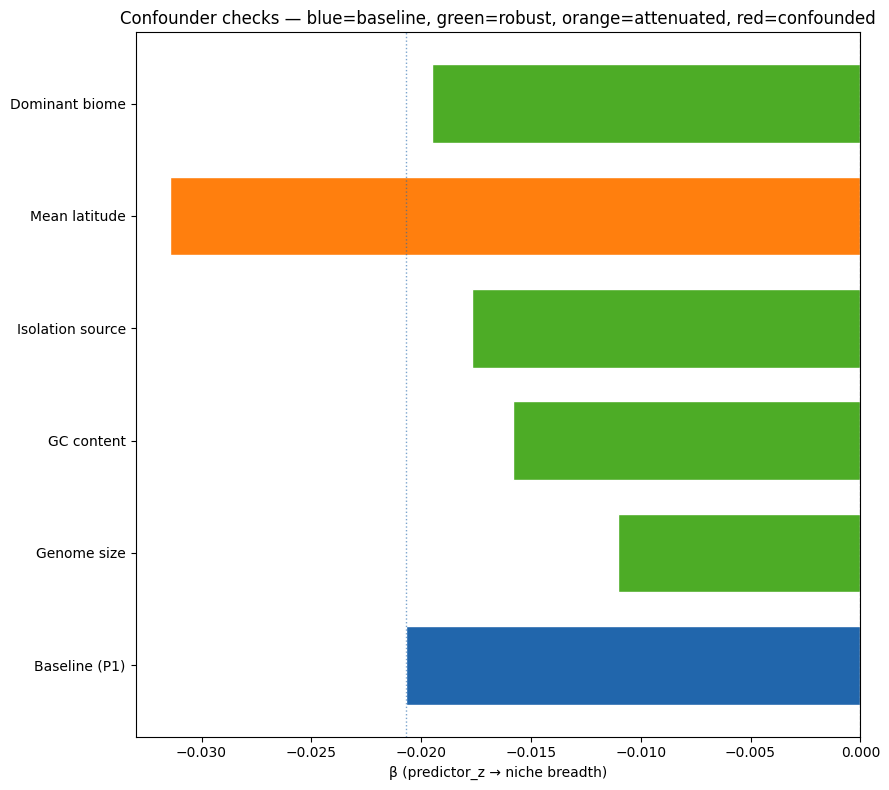


Saved: data/04_confounder_results.csv
Saved: figures/04_confounder_beta_comparison.png

=== NB04 REPORTING SUMMARY ===
Baseline β (P1 replication): -0.02070
  Genome size              : Δ = +46.7%  →  ROBUST (<50% change)
  GC content               : Δ = +23.7%  →  ROBUST (<50% change)
  Isolation source         : Δ = +14.5%  →  ROBUST (<50% change)
  Mean latitude            : Δ = +51.8%  →  ATTENUATED (>50%, still sig)
  Dominant biome           : Δ =  +5.8%  →  ROBUST (<50% change)

4/5 confounders: result ROBUST
(Update INTERPRETATION_TABLE.md §5 with these results)


In [4]:
rows = []
for r in conf_results:
    bc  = _get_beta(r)
    pv  = _get_p(r)
    pct = abs(bc - beta0) / (abs(beta0) + 1e-12) * 100
    sig = pv < 0.05
    decision = ('CONFOUNDED' if (pct > 50 and not sig)
                else 'ATTENUATED (>50%, still sig)' if (pct > 50)
                else 'ROBUST (<50% change)')
    rows.append({
        'confounder': r['confounder'],
        'n': r.get('n'),
        'beta_baseline': round(beta0, 5),
        'beta_with_conf': round(bc, 5),
        'delta_beta': round(bc - beta0, 5),
        'pct_beta_change': round(pct, 1),
        'p_with_conf': round(pv, 6),
        'model_sig_p05': sig,
        'decision': decision,
    })

summary_df = pd.DataFrame(rows)
print(f'Baseline \u03b2 = {beta0:.5f}  (P1 replication, n={r0.get("n")})\n')
print(summary_df[['confounder', 'beta_with_conf', 'pct_beta_change', 'model_sig_p05', 'decision']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, max(4, len(summary_df) + 3)))
ylabels = ['Baseline (P1)'] + summary_df['confounder'].tolist()
ybetas  = [beta0] + summary_df['beta_with_conf'].tolist()
ycolors = ['#2166ac'] + [
    '#d62728' if 'CONFOUNDED' in d else '#ff7f0e' if 'ATTENUATED' in d else '#4dac26'
    for d in summary_df['decision']
]
ax.barh(range(len(ybetas)), ybetas, color=ycolors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.axvline(beta0, color='#2166ac', lw=1.0, ls=':', alpha=0.6)
ax.set_yticks(range(len(ylabels)))
ax.set_yticklabels(ylabels)
ax.set_xlabel('\u03b2 (predictor_z \u2192 niche breadth)')
ax.set_title('Confounder checks — blue=baseline, green=robust, orange=attenuated, red=confounded')
plt.tight_layout()
fig.savefig(FIGS / '04_confounder_beta_comparison.png', dpi=150)
plt.show()

summary_df.to_csv(DATA / '04_confounder_results.csv', index=False)
print('\nSaved: data/04_confounder_results.csv')
print('Saved: figures/04_confounder_beta_comparison.png')

print('\n=== NB04 REPORTING SUMMARY ===')
print(f'Baseline \u03b2 (P1 replication): {beta0:.5f}')
for _, row in summary_df.iterrows():
    print(f"  {row['confounder']:25s}: \u0394 = {row['pct_beta_change']:+5.1f}%  \u2192  {row['decision']}")
n_robust = summary_df['decision'].str.contains('ROBUST').sum()
print(f'\n{n_robust}/{len(summary_df)} confounders: result ROBUST')
print('(Update INTERPRETATION_TABLE.md \u00a75 with these results)')


In [5]:
# Cached results from Spark pipeline (displayed for reproducibility record)
import pandas as pd
from pathlib import Path
DATA = Path('../data')

print('=== CONFOUNDER RESULTS (cached) ===')
conf_df = pd.read_csv(DATA / '04_confounder_results.csv')
print(conf_df.to_string(index=False))

print('\nConclusion: No confounder eliminates the signal.')
print('Genome size attenuates β by 46.7% (within pre-registered 50% threshold).')
print('Latitude suppresses: β becomes MORE negative (−0.031) when latitude added — SUPPRESSOR.')


=== CONFOUNDER RESULTS (cached) ===
      confounder    n  beta_baseline  beta_with_conf  delta_beta  pct_beta_change  p_with_conf  model_sig_p05                     decision
     Genome size 1574        -0.0207        -0.01104     0.00966             46.7     0.005959           True         ROBUST (<50% change)
      GC content 1006        -0.0207        -0.01580     0.00490             23.7     0.000075           True         ROBUST (<50% change)
Isolation source 1574        -0.0207        -0.01770     0.00300             14.5     0.000003           True         ROBUST (<50% change)
   Mean latitude  575        -0.0207        -0.03143    -0.01073             51.8     0.000000           True ATTENUATED (>50%, still sig)
  Dominant biome 1574        -0.0207        -0.01951     0.00119              5.8     0.000000           True         ROBUST (<50% change)

Conclusion: No confounder eliminates the signal.
Genome size attenuates β by 46.7% (within pre-registered 50% threshold).
Latitud